In [6]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MAE
from neuralforecast.tsdataset import TimeSeriesDataModule
from IPython.display import Image


# Model architecture

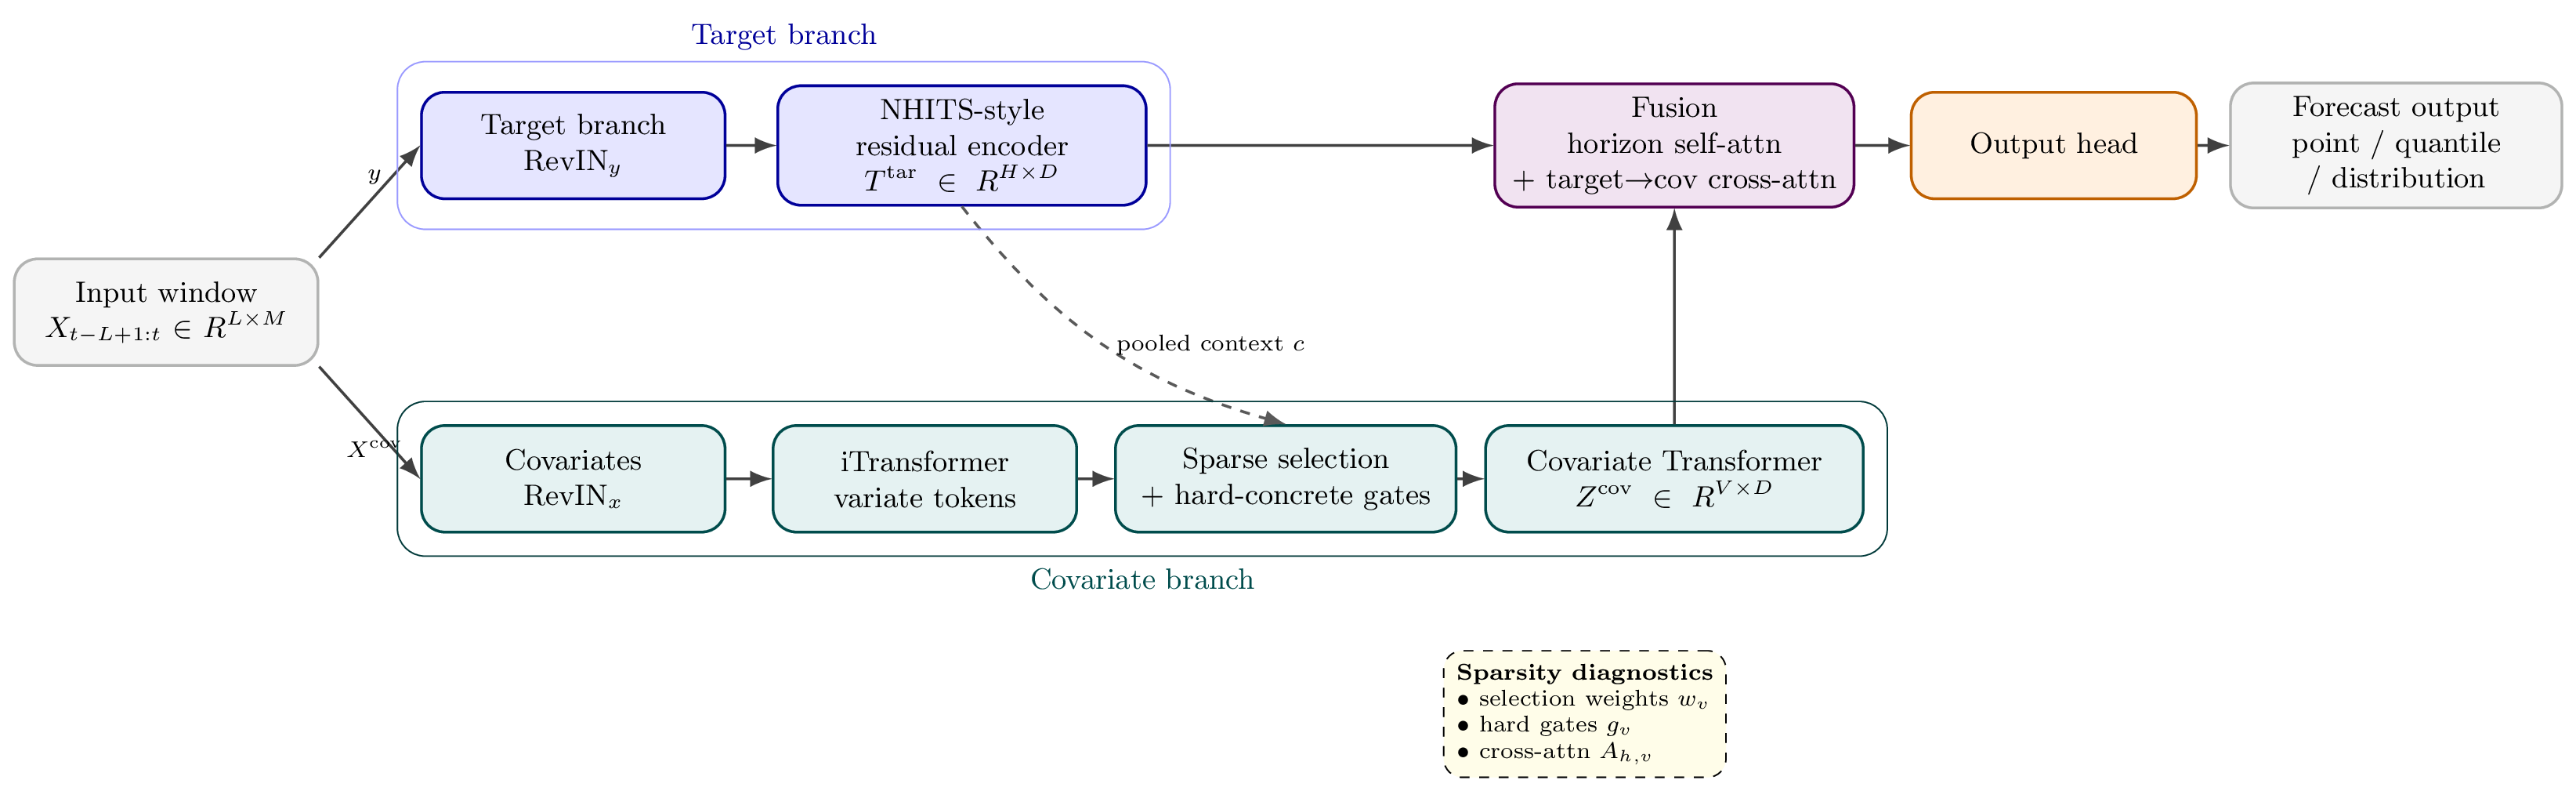

In [7]:
Image(filename="architecture_ML.png")

# NHITS Style Residual Encoder

Seed set to 29


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Stack 1 residual identity max error: 0.000e+00
Stack 2 residual identity max error: 0.000e+00
Stack 3 residual identity max error: 0.000e+00


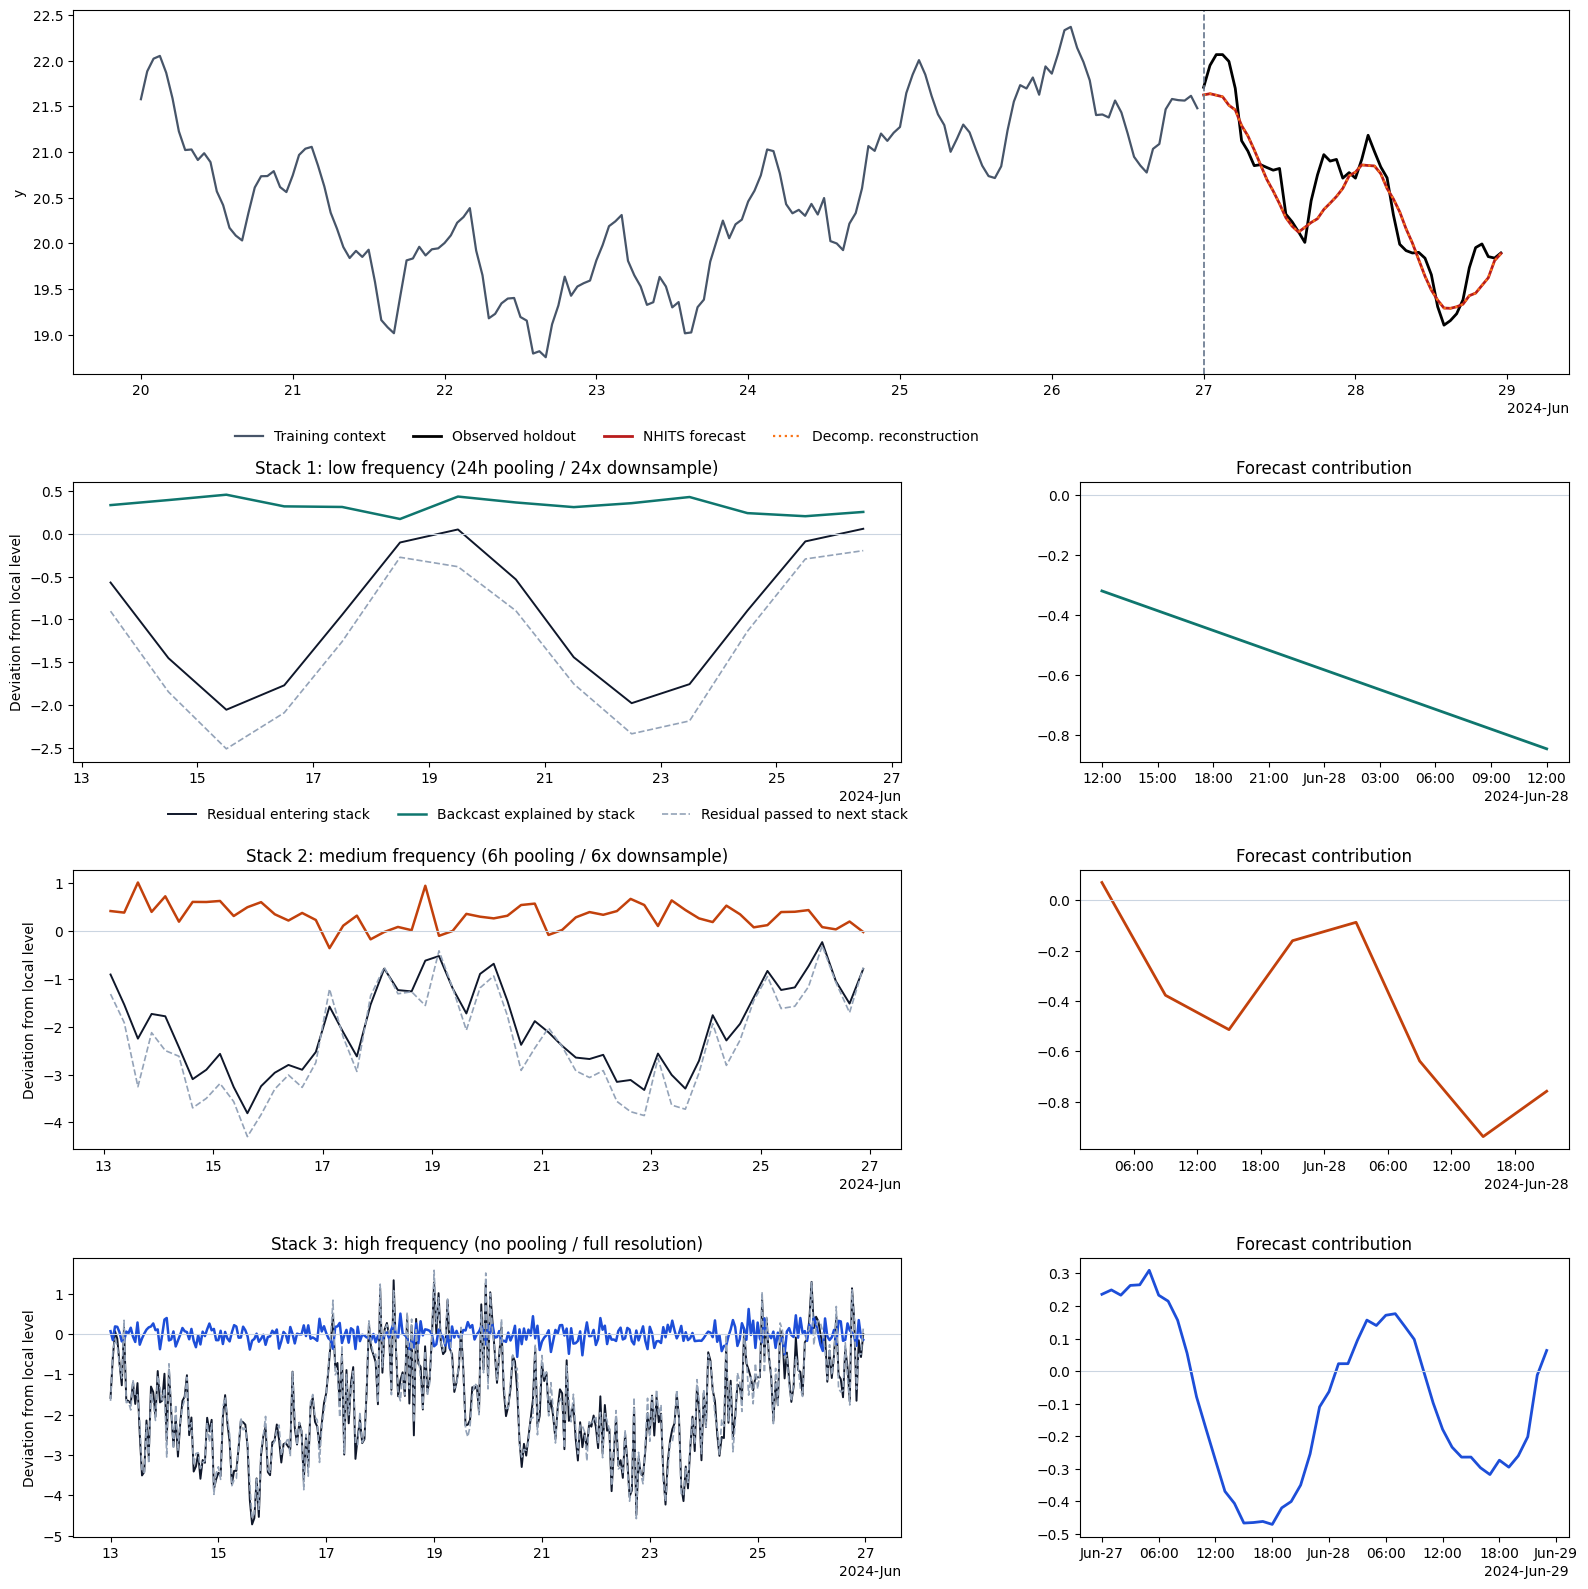

,ds,y,y_hat,abs_error
43,2024-06-28 19:00:00,19.952768,19.454235,0.498533
44,2024-06-28 20:00:00,19.992864,19.538561,0.454303
45,2024-06-28 21:00:00,19.853978,19.621803,0.232175
46,2024-06-28 22:00:00,19.838222,19.810858,0.027365
47,2024-06-28 23:00:00,19.894101,19.886988,0.007113


In [ ]:
h = 48
input_size = 24 * 14

def _apply_date_format(ax):
    loc = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))


def _as_int_kernel(k):
    if isinstance(k, tuple):
        return int(k[0])
    if isinstance(k, list):
        return int(k[0])
    return int(k)


def _pool_series(times, values, pool_k):
    """
    Average-pool a time series for display.
    Each pool window is represented by its midpoint timestamp.
    """
    pool_k = _as_int_kernel(pool_k)

    times = np.asarray(times)
    values = np.asarray(values, dtype=float)

    if pool_k <= 1 or len(values) < pool_k:
        return times, values

    n_pooled = len(values) // pool_k
    v = values[: n_pooled * pool_k].reshape(n_pooled, pool_k).mean(axis=1)
    t = times[: n_pooled * pool_k].reshape(n_pooled, pool_k)[:, pool_k // 2]
    return t, v


def _move_to_device(obj, device):
    if torch.is_tensor(obj):
        return obj.to(device)
    if isinstance(obj, dict):
        return {k: _move_to_device(v, device) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_move_to_device(v, device) for v in obj]
    if isinstance(obj, tuple):
        return tuple(_move_to_device(v, device) for v in obj)
    return obj

def make_synthetic_hourly_series(n_points=24 * 180, seed=21):
    rng = np.random.default_rng(seed)
    ds = pd.date_range("2024-01-01", periods=n_points, freq="h")
    t = np.arange(n_points)

    trend = 0.003 * t / 24
    weekly = 1.10 * np.sin(2 * np.pi * t / (24 * 7) - 0.4)
    daily = 0.55 * np.sin(2 * np.pi * t / 24 + 1.1)
    intraday = 0.25 * np.sin(2 * np.pi * t / 8 - 0.8)
    noise = 0.08 * rng.normal(size=n_points)

    y = 20 + trend + weekly + daily + intraday + noise

    return pd.DataFrame({
        "unique_id": "synthetic_pooltick",
        "ds": ds,
        "y": y,
        "trend": trend,
        "weekly": weekly,
        "daily": daily,
        "intraday": intraday,
        "noise": noise,
    })


def make_demo_nhits(
    h=48,
    input_size=24 * 14,
    max_steps=300,
    learning_rate=1e-3,
    random_seed=7,
):
    return NHITS(
        h=h,
        input_size=input_size,
        stack_types=["identity", "identity", "identity"],
        n_blocks=[1, 1, 1],
        mlp_units=[[128, 128], [128, 128], [128, 128]],
        n_pool_kernel_size=[24, 6, 1],
        n_freq_downsample=[24, 6, 1],
        pooling_mode="MaxPool1d",
        interpolation_mode="linear",
        activation="ReLU",
        loss=MAE(),
        scaler_type="identity",
        max_steps=max_steps,
        learning_rate=learning_rate,
        batch_size=32,
        windows_batch_size=256,
        inference_windows_batch_size=-1,
        early_stop_patience_steps=-1,
        val_check_steps=50,
        random_seed=random_seed,
        enable_progress_bar=False,
        enable_checkpointing=False,
        enable_model_summary=False,
        logger=False,
    )

def split_last_horizon(series_df, h, max_points=None):
    series = (
        series_df[["unique_id", "ds", "y"]]
        .copy()
        .sort_values(["unique_id", "ds"])
        .reset_index(drop=True)
    )
    series["ds"] = pd.to_datetime(series["ds"]).dt.tz_localize(None)

    if max_points is not None:
        series = (
            series.groupby("unique_id", group_keys=False, sort=False)
            .tail(max_points)
            .reset_index(drop=True)
        )

    train_parts, test_parts = [], []

    for _, group in series.groupby("unique_id", sort=False):
        if len(group) <= h:
            raise ValueError("Each series needs more than h observations.")
        train_parts.append(group.iloc[:-h])
        test_parts.append(group.iloc[-h:])

    return (
        pd.concat(train_parts, ignore_index=True),
        pd.concat(test_parts, ignore_index=True),
    )

def extract_nhits_stack_interpretation(nf):
    """
    Extract NHITS block-level residual inputs, backcasts, residual outputs,
    and forecast contributions for the final prediction window.

    Important orientation:
      - NHITS internally uses reversed insample residuals.
      - For plotting, arrays are flipped back to chronological order.
    """
    model = nf.models[0]
    model.eval()

    device = next(model.parameters()).device

    datamodule = TimeSeriesDataModule(dataset=nf.dataset, valid_batch_size=1)
    datamodule.setup(stage="predict")
    batch = next(iter(datamodule.predict_dataloader()))
    batch = _move_to_device(batch, device)

    # Select final prediction window
    windows_all = model._create_windows(batch, step="predict")
    last_window_idx = np.array([len(windows_all["temporal"]) - 1])

    windows = model._create_windows(batch, step="predict", w_idxs=last_window_idx)

    norm_out = model._normalization(windows=windows, y_idx=batch["y_idx"])
    if isinstance(norm_out, tuple):
        windows = norm_out[0]
    else:
        windows = norm_out

    insample_y, insample_mask, _, _, hist_exog, futr_exog, stat_exog = model._parse_windows(
        batch, windows
    )

    # Internal NHITS residual orientation
    residuals = insample_y.flip(dims=(-1,))
    insample_mask = insample_mask.flip(dims=(-1,))

    # NHITS level/naive component used in forecast reconstruction
    level = insample_y[:, -1:, None]
    level_component = (
        level.repeat(1, model.h, 1)
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
        .squeeze(-1)
    )

    residual_inputs = []
    backcasts = []
    residual_outputs = []
    stack_components = []

    with torch.no_grad():
        for block in model.blocks:
            # Store residual entering stack in chronological order
            residual_inputs.append(
                residuals.squeeze(0).detach().cpu().numpy()[::-1].copy()
            )

            backcast, block_forecast = block(
                insample_y=residuals,
                futr_exog=futr_exog,
                hist_exog=hist_exog,
                stat_exog=stat_exog,
            )

            # Store backcast in chronological order
            backcasts.append(
                backcast.squeeze(0).detach().cpu().numpy()[::-1].copy()
            )

            residuals = (residuals - backcast) * insample_mask

            # Store residual leaving stack in chronological order
            residual_outputs.append(
                residuals.squeeze(0).detach().cpu().numpy()[::-1].copy()
            )

            fc = block_forecast.squeeze(0).detach().cpu().numpy()
            fc = np.squeeze(fc)
            stack_components.append(fc.copy())

    stack_components = np.vstack(stack_components)
    total_forecast = level_component + stack_components.sum(axis=0)

    pool_kernel_sizes = []
    for block in model.blocks:
        if hasattr(block, "pooling_layer"):
            pool_kernel_sizes.append(_as_int_kernel(block.pooling_layer.kernel_size))
        else:
            pool_kernel_sizes.append(1)

    freq_downsample_sizes = list(model.hparams.get("n_freq_downsample", [1] * len(model.blocks)))
    freq_downsample_sizes = [_as_int_kernel(x) for x in freq_downsample_sizes]

    stack_labels = [
        "Stack 1: low frequency (24h pooling / 24x downsample)",
        "Stack 2: medium frequency (6h pooling / 6x downsample)",
        "Stack 3: high frequency (no pooling / full resolution)",
    ]

    # Sanity check: residual_in - backcast == residual_out
    for i in range(len(backcasts)):
        err = np.max(np.abs(residual_inputs[i] - backcasts[i] - residual_outputs[i]))
        print(f"Stack {i+1} residual identity max error: {err:.3e}")

    return {
        "context": insample_y.squeeze(0).detach().cpu().numpy().copy(),
        "level": level_component,
        "stack_components": stack_components,
        "forecast": total_forecast,
        "residual_inputs": residual_inputs,
        "backcasts": backcasts,
        "residual_outputs": residual_outputs,
        "stack_labels": stack_labels,
        "pool_kernel_sizes": pool_kernel_sizes,
        "freq_downsample_sizes": freq_downsample_sizes,
    }

def fit_nhits_demo(
    series_df,
    h=48,
    input_size=24 * 14,
    max_steps=300,
    max_points=None,
    random_seed=7,
):
    train_df, test_df = split_last_horizon(series_df, h=h, max_points=max_points)

    model = make_demo_nhits(
        h=h,
        input_size=input_size,
        max_steps=max_steps,
        random_seed=random_seed,
    )

    nf = NeuralForecast(models=[model], freq="h")
    nf.fit(df=train_df)

    forecast_df = nf.predict()

    if not {"unique_id", "ds"}.issubset(forecast_df.columns):
        forecast_df = forecast_df.reset_index()

    forecast_df = forecast_df.drop(columns=["index", "level_0"], errors="ignore")

    model_cols = [c for c in forecast_df.columns if c not in ["unique_id", "ds"]]
    model_col = model_cols[-1]

    forecast_df = (
        forecast_df[["unique_id", "ds", model_col]]
        .copy()
        .rename(columns={model_col: "y_hat"})
    )
    forecast_df["ds"] = pd.to_datetime(forecast_df["ds"])

    interpretation = extract_nhits_stack_interpretation(nf)

    return nf, train_df, test_df, forecast_df, interpretation
def plot_nhits_stack_decomposition_fixed(
    train_df,
    test_df,
    forecast_df,
    interpretation,
    title,
    context_points=24 * 7,
    save_path=None,
):
    n_stacks = len(interpretation["stack_labels"])
    colors = ["#0f766e", "#c2410c", "#1d4ed8"]

    pool_kernel_sizes = interpretation.get("pool_kernel_sizes", [1] * n_stacks)
    freq_downsample_sizes = interpretation.get("freq_downsample_sizes", [1] * n_stacks)

    context_df = train_df.tail(len(interpretation["context"])).copy()
    context_display = context_df.tail(min(context_points, len(context_df)))

    forecast_view = forecast_df[["ds", "y_hat"]].copy()
    forecast_view["ds"] = pd.to_datetime(forecast_view["ds"])
    forecast_ds = forecast_view["ds"].values

    fig = plt.figure(figsize=(16, 4 * (n_stacks + 1)))
    gs = fig.add_gridspec(
        n_stacks + 1,
        2,
        width_ratios=[2.2, 1.3],
        height_ratios=[1.3] + [1] * n_stacks,
    )
    ax_top = fig.add_subplot(gs[0, :])

    ax_top.plot(
        context_display["ds"],
        context_display["y"],
        color="#475569",
        lw=1.6,
        label="Training context",
    )
    ax_top.plot(
        test_df["ds"],
        test_df["y"],
        color="black",
        lw=2.0,
        label="Observed holdout",
    )
    ax_top.plot(
        forecast_view["ds"],
        forecast_view["y_hat"],
        color="#b91c1c",
        lw=2.0,
        label="NHITS forecast",
    )
    ax_top.plot(
        forecast_view["ds"],
        interpretation["forecast"],
        color="#f97316",
        lw=1.6,
        linestyle=":",
        label="Decomp. reconstruction",
    )

    ax_top.axvline(test_df["ds"].iloc[0], color="#64748b", lw=1.2, linestyle="--")
    # ax_top.set_title(title)
    ax_top.set_ylabel("y")
    ax_top.legend(bbox_to_anchor=(0.1, -0.12), ncols=4, loc="upper left", frameon=False)
    _apply_date_format(ax_top)

    for stack_idx, label in enumerate(interpretation["stack_labels"]):
        ax_left = fig.add_subplot(gs[stack_idx + 1, 0])
        ax_right = fig.add_subplot(gs[stack_idx + 1, 1])

        pool_k = pool_kernel_sizes[stack_idx]
        freq_ds = freq_downsample_sizes[stack_idx]

        residual_in_raw = np.asarray(interpretation["residual_inputs"][stack_idx], dtype=float)
        backcast_raw = np.asarray(interpretation["backcasts"][stack_idx], dtype=float)
        residual_out_raw = np.asarray(interpretation["residual_outputs"][stack_idx], dtype=float)

        # Local centering for visual readability
        local_level = float(residual_in_raw[-1])

        residual_in = residual_in_raw - local_level
        residual_out = residual_out_raw - local_level

        backcast_dev = backcast_raw

        context_times = context_df["ds"].values

        left_t, residual_in_p = _pool_series(context_times, residual_in, pool_k)
        _, backcast_p = _pool_series(context_times, backcast_dev, pool_k)
        _, residual_out_p = _pool_series(context_times, residual_out, pool_k)

        ax_left.plot(
            left_t,
            residual_in_p,
            color="#0f172a",
            lw=1.4,
            label="Residual entering stack",
        )
        ax_left.plot(
            left_t,
            backcast_p,
            color=colors[stack_idx],
            lw=1.8,
            label="Backcast explained by stack",
        )
        ax_left.plot(
            left_t,
            residual_out_p,
            color="#94a3b8",
            lw=1.2,
            linestyle="--",
            label="Residual passed to next stack",
        )

        ax_left.axhline(0.0, color="#cbd5e1", lw=0.8)
        ax_left.set_title(label)
        ax_left.set_ylabel("Deviation from local level")
        _apply_date_format(ax_left)

        # Forecast contribution
        fc_vals = np.asarray(interpretation["stack_components"][stack_idx], dtype=float)
        right_t, fc_vals_p = _pool_series(forecast_ds, fc_vals, freq_ds)

        ax_right.plot(right_t, fc_vals_p, color=colors[stack_idx], lw=2.0)
        ax_right.axhline(0.0, color="#cbd5e1", lw=0.8)
        ax_right.set_title("Forecast contribution")
        _apply_date_format(ax_right)

        if stack_idx == 0:
            ax_left.legend(bbox_to_anchor=(0.1, -0.12), ncols=3, loc="upper left", frameon=False)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, transparent=True, bbox_inches="tight")

    plt.show()

synthetic_df = make_synthetic_hourly_series(n_points=24 * 180, seed=21)

nf, synth_train_df, synth_test_df, synth_forecast_df, synth_interp = fit_nhits_demo(
    synthetic_df[["unique_id", "ds", "y"]],
    h=h,
    input_size=input_size,
    max_steps=300,
    max_points=None,
    random_seed=29,
)

plot_nhits_stack_decomposition_fixed(
    train_df=synth_train_df,
    test_df=synth_test_df,
    forecast_df=synth_forecast_df,
    interpretation=synth_interp,
    title="NHITS stack-wise residual decomposition on synthetic trend + multi-seasonality",
    context_points=24 * 7,
    save_path="nhits_stack_decomposition_fixed.png",
)

synth_results = synth_test_df.merge(
    synth_forecast_df,
    on=["unique_id", "ds"],
    how="left",
)

synth_results["abs_error"] = (synth_results["y"] - synth_results["y_hat"]).abs()
synth_results[["ds", "y", "y_hat", "abs_error"]].tail()

## L0 Regularization and Hard Concrete Distribution Gating

**L0 Regularization** encourages sparsity by penalizing the expected number of non-zero activations in a neural network. This helps with:
- Feature selection: identifying which inputs or hidden units are truly important
- Model compression: reducing parameters by zeroing out unnecessary connections
- Interpretability: understanding which features drive predictions

**Hard Concrete Distribution** is used for differentiable gating in L0-constrained neural networks. It's a sophisticated approach to enforce binary gating while maintaining differentiability:

1. **Bernoulli distribution**: Traditional discrete gating (z ∈ {0, 1}) - not differentiable for backprop
2. **Concrete distribution**: Continuous relaxation of Bernoulli on (0, 1) - differentiable but doesn't give hard 0/1 values
3. **Hard Concrete distribution**: Clipped stretch of Concrete with point masses at 0 and 1 - combines differentiability with hard gating at the boundaries

The hard concrete distribution parameters allow fine control over sparsity: the probability of gating (setting to 0), the continuous region, and full activation.

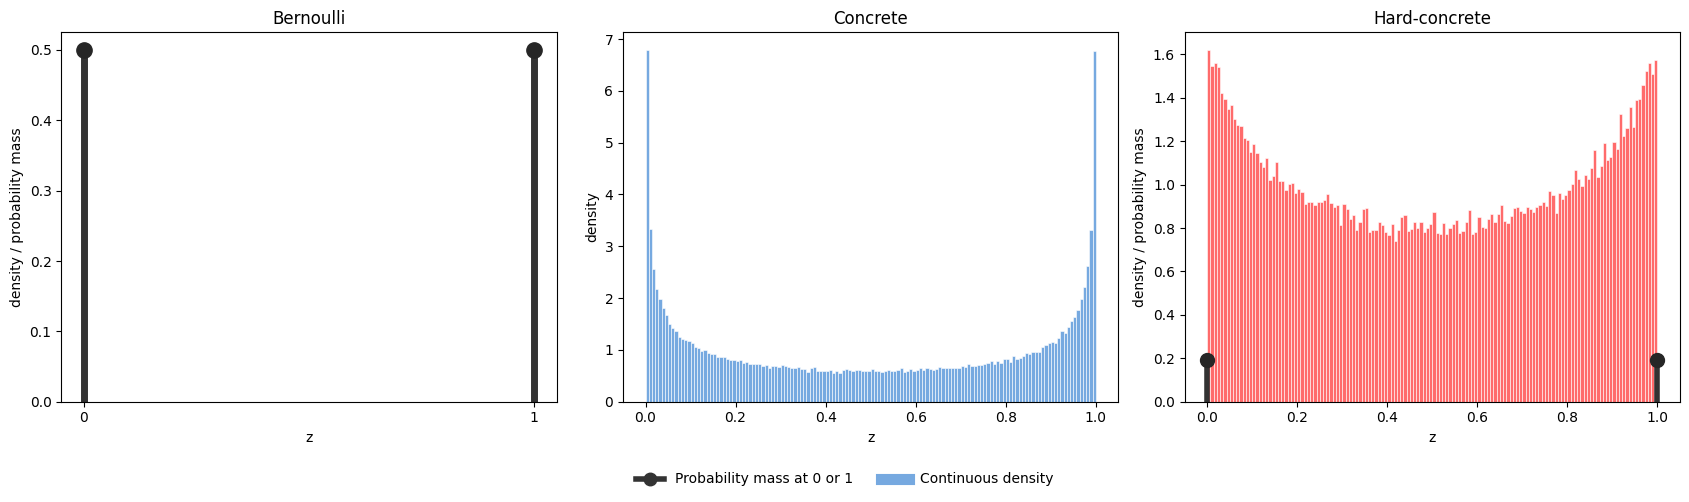

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# Parameters for the distributions
loc = 0.0
tau = 0.6
gamma = -0.1
zeta = 1.1
n_samples = 200_000
rng = np.random.default_rng(7)

# Shared latent samples
u = rng.uniform(1e-6, 1 - 1e-6, size=n_samples)
logits = np.log(u) - np.log1p(-u)

# Bernoulli gate probability
pi = sigmoid(loc)

# Concrete samples in (0, 1)
concrete_samples = sigmoid((logits + loc) / tau)

# Hard-concrete samples after stretch and clipping
stretched_samples = concrete_samples * (zeta - gamma) + gamma
hard_concrete_samples = np.clip(stretched_samples, 0.0, 1.0)

# Exact boundary masses for hard concrete
left_boundary = sigmoid(tau * np.log(-gamma / zeta) - loc)
right_boundary = 1 - sigmoid(tau * np.log((1 - gamma) / (zeta - 1)) - loc)

# Interior samples only for the continuous density view
hard_interior = hard_concrete_samples[(hard_concrete_samples > 0) & (hard_concrete_samples < 1)]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- 1. Bernoulli ---
ax = axes[0]
bernoulli_x = np.array([0.0, 1.0])
bernoulli_mass = np.array([1 - pi, pi])
markerline, stemlines, baseline = ax.stem(bernoulli_x, bernoulli_mass, linefmt='0.25', markerfmt='o', basefmt=' ')
plt.setp(stemlines, linewidth=5, color='0.2')
plt.setp(markerline, markersize=11, markerfacecolor='0.15', markeredgecolor='0.15')
ax.set_title('Bernoulli')
ax.set_xlabel('z')
ax.set_ylabel('density / probability mass')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0, 1.05 * bernoulli_mass.max())
ax.set_xticks([0, 1])

# --- 2. Concrete ---
ax = axes[1]
ax.hist(
    concrete_samples,
    bins=140,
    range=(0, 1),
    density=True,
    color='#76a9e0',
    edgecolor='white',
    linewidth=0.4,
)
ax.set_title('Concrete')
ax.set_xlabel('z')
ax.set_ylabel('density')
ax.set_xlim(-0.05, 1.05)

# --- 3. Hard-concrete ---
ax = axes[2]
ax.hist(
    hard_interior,
    bins=140,
    range=(0, 1),
    density=True,
    color='#ff6b6b',
    edgecolor='white',
    linewidth=0.4,
)
markerline, stemlines, baseline = ax.stem([0.0, 1.0], [left_boundary, right_boundary], linefmt='0.25', markerfmt='o', basefmt=' ')
plt.setp(stemlines, linewidth=4, color='0.2')
plt.setp(markerline, markersize=10, markerfacecolor='0.15', markeredgecolor='0.15')
ax.set_title('Hard-concrete')
ax.set_xlabel('z')
ax.set_ylabel('density / probability mass')
ax.set_xlim(-0.05, 1.05)

legend_handles = [
    Line2D([0], [0], color='0.2', marker='o', linewidth=4, markersize=9, label='Probability mass at 0 or 1'),
    Line2D([0], [0], color='#76a9e0', linewidth=8, label='Continuous density'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0))

plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.savefig('hard_concrete_plot.png', dpi=300, transparent=True, bbox_inches='tight')